# Test for Equal Variances

**Module 5: Numerical Outcomes** | Lean Six Sigma Data Analytics

---

## The Law of Variability

> **"Increasing variability always degrades the performance of a production system."**
> — Hopp and Spearman

This law shows that understanding variation is very important for the quality of a process. Therefore, we want to study variability across groups using a **test for equal variances**.

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for equal variances analysis!')

Ready for equal variances analysis!


---

## Example: Coffee Machine Consistency

Let's go back to the example of four machines producing coffee. Together, we investigated that the average moisture content of the coffee beans depended on the machine it was produced on.

We showed that the means of moisture percentage differ across the four machines. But what about the **variation within a machine**?

- Machine 2 has a wide range of moisture contents
- Machine 4 appeared a lot more consistent

For producing consistent coffee, we probably want the machine with the smallest variation.

In [2]:
# Load moisture data (stacked format as shown in Minitab)
def load_moisture():
    df = pd.read_excel(xlsx, sheet_name='Moisture', skiprows=7, header=None, usecols=[0,1,2,3])
    df.columns = ['Machine_1', 'Machine_2', 'Machine_3', 'Machine_4']
    df_long = df.melt(var_name='Machine', value_name='Moisture').dropna()
    df_long['Machine'] = df_long['Machine'].str.replace('Machine_', '')
    return df_long

moisture = load_moisture()

print('MOISTURE DATA BY MACHINE')
print('=' * 60)
print(f'Total observations: {len(moisture)}')
print()
print('Summary Statistics:')
summary = moisture.groupby('Machine')['Moisture'].agg(['count', 'mean', 'std'])
summary.columns = ['N', 'Mean', 'Std Dev']
print(summary.round(4))

MOISTURE DATA BY MACHINE
Total observations: 40

Summary Statistics:
          N    Mean  Std Dev
Machine                     
1        10  11.913   1.4169
2        10   9.655   2.1099
3        10  11.075   1.9482
4        10   9.729   1.0347


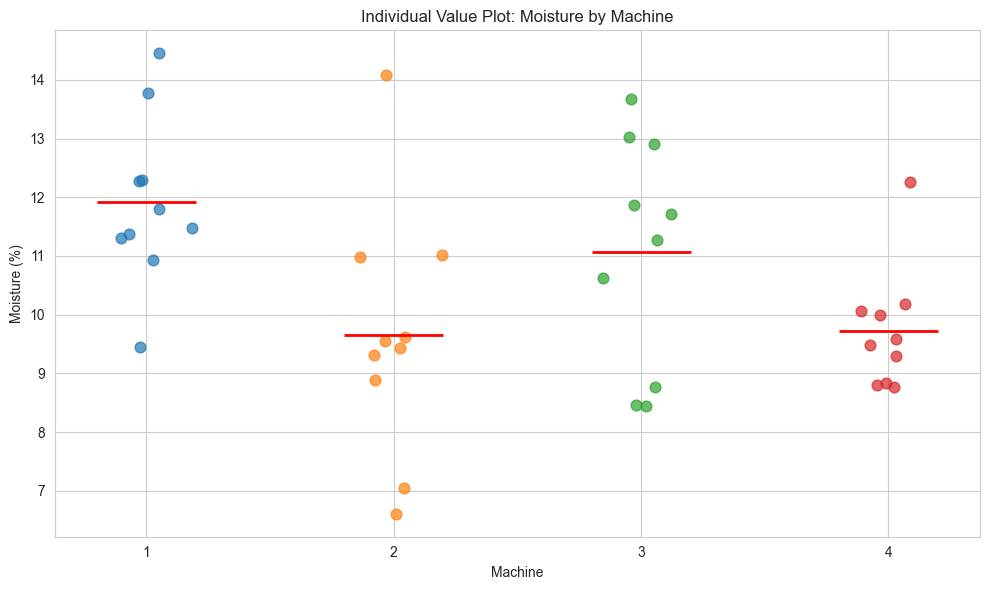

OBSERVATION:
  Machine 2 has a WIDE range of moisture contents
  Machine 4 appears more CONSISTENT


In [3]:
# Individual value plot showing the data
fig, ax = plt.subplots(figsize=(10, 6))

for i, machine in enumerate(['1', '2', '3', '4']):
    data = moisture[moisture['Machine'] == machine]['Moisture']
    x = np.random.normal(i, 0.08, size=len(data))
    ax.scatter(x, data, alpha=0.7, s=60)
    
    # Add mean line
    mean = data.mean()
    ax.hlines(mean, i-0.2, i+0.2, colors='red', linewidths=2)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['1', '2', '3', '4'])
ax.set_xlabel('Machine')
ax.set_ylabel('Moisture (%)')
ax.set_title('Individual Value Plot: Moisture by Machine')

plt.tight_layout()
plt.show()

print('OBSERVATION:')
print('  Machine 2 has a WIDE range of moisture contents')
print('  Machine 4 appears more CONSISTENT')

---

## Focus: Machine 2 vs Machine 4

Let's take a closer look at these two machines:
- The mean level is near equal for Machine 2 and 4
- However, the variation of the two machines may differ

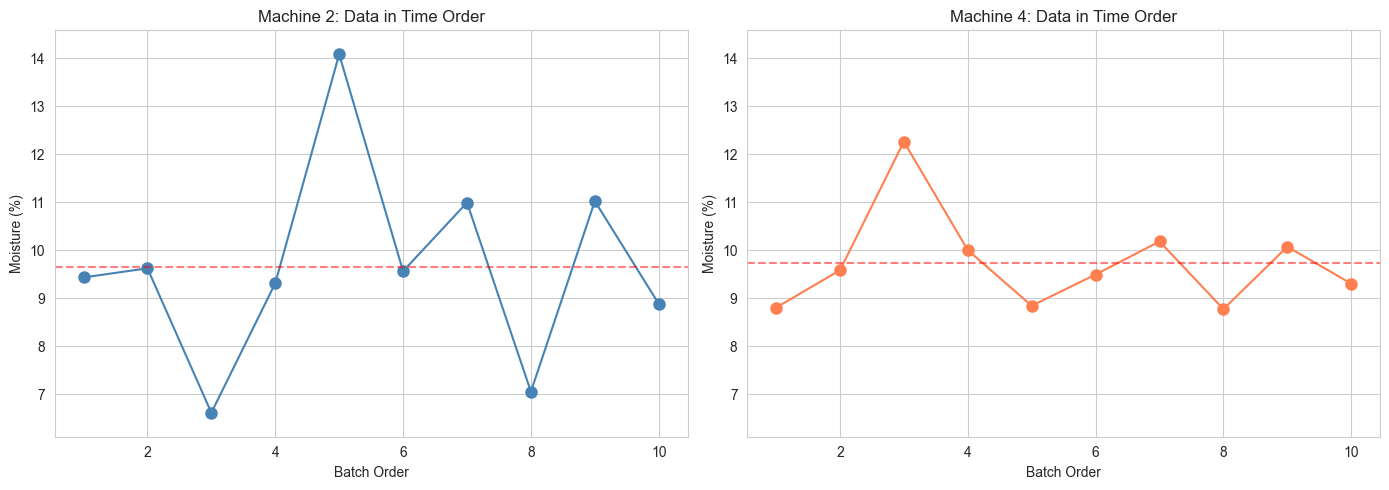

The moisture content of Machine 2 goes up and down more than that of Machine 4.


In [4]:
# Data in time order for Machine 2 and Machine 4
machine_2 = moisture[moisture['Machine'] == '2']['Moisture'].values
machine_4 = moisture[moisture['Machine'] == '4']['Moisture'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Machine 2 time order
axes[0].plot(range(1, len(machine_2)+1), machine_2, 'o-', color='steelblue', 
             linewidth=1.5, markersize=8)
axes[0].axhline(machine_2.mean(), color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Batch Order')
axes[0].set_ylabel('Moisture (%)')
axes[0].set_title('Machine 2: Data in Time Order')

# Machine 4 time order
axes[1].plot(range(1, len(machine_4)+1), machine_4, 'o-', color='coral',
             linewidth=1.5, markersize=8)
axes[1].axhline(machine_4.mean(), color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Batch Order')
axes[1].set_ylabel('Moisture (%)')
axes[1].set_title('Machine 4: Data in Time Order')

# Set same y-axis limits for comparison
y_min = min(machine_2.min(), machine_4.min()) - 0.5
y_max = max(machine_2.max(), machine_4.max()) + 0.5
axes[0].set_ylim(y_min, y_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

print('The moisture content of Machine 2 goes up and down more than that of Machine 4.')

---

## Why Variation Matters

If the machine produces very inconsistently (a lot of variation), this might cause problems:
- It could lead to a lot of **scrap and defects** which will cost you money

If you want your moisture percentage to be, for instance, **lower than 10.5%**:
- With a lot of variation (like Machine 2), many batches will exceed this limit
- These batches will have to be **thrown away or reprocessed**
- With smaller variation (like Machine 4), this will happen less often

Therefore, you will probably like to know if one of the machines produces more consistently than the others.

---

## Standard Deviations from ANOVA Output

The output of the ANOVA analysis already gave us some information on the variation. We see that Machine 4 has a smaller standard deviation and therefore produces most consistently—within the sample at least.

**But are these differences between the standard deviations statistically significant, or is it a coincidence that Machine 4 has the smallest variation?**

Let us use a statistical test: the **test for equality of variances**.

In [5]:
# Display standard deviations
print('STANDARD DEVIATIONS BY MACHINE')
print('=' * 40)
for machine in ['1', '2', '3', '4']:
    data = moisture[moisture['Machine'] == machine]['Moisture']
    print(f'  Machine {machine}: Std Dev = {data.std():.4f}')
print()
print('Machine 4 has the smallest standard deviation in the sample.')
print('But is this statistically significant?')

STANDARD DEVIATIONS BY MACHINE
  Machine 1: Std Dev = 1.4169
  Machine 2: Std Dev = 2.1099
  Machine 3: Std Dev = 1.9482
  Machine 4: Std Dev = 1.0347

Machine 4 has the smallest standard deviation in the sample.
But is this statistically significant?


---

## Test for Equal Variances

In Minitab: **Stat > ANOVA > Test for Equal Variances**
- Response: Moisture
- Factors: Machine

We use **Levene's test** to check if the differences between variances are statistically significant.

In [6]:
# Perform Levene's test for equal variances
machine_1 = moisture[moisture['Machine'] == '1']['Moisture'].values
machine_2 = moisture[moisture['Machine'] == '2']['Moisture'].values
machine_3 = moisture[moisture['Machine'] == '3']['Moisture'].values
machine_4 = moisture[moisture['Machine'] == '4']['Moisture'].values

stat, p_value = stats.levene(machine_1, machine_2, machine_3, machine_4)

print('TEST FOR EQUAL VARIANCES')
print('=' * 60)
print()
print('Estimates for Standard Deviation:')
print('-' * 40)
for i, (name, data) in enumerate([('1', machine_1), ('2', machine_2), 
                                   ('3', machine_3), ('4', machine_4)]):
    print(f'  Machine {name}: {data.std():.4f}')
print()
print("Levene's Test:")
print('-' * 40)
print(f'  Test statistic: {stat:.4f}')
print(f'  P-value: {p_value:.4f} ({p_value*100:.1f}%)')

TEST FOR EQUAL VARIANCES

Estimates for Standard Deviation:
----------------------------------------
  Machine 1: 1.3442
  Machine 2: 2.0016
  Machine 3: 1.8482
  Machine 4: 0.9816

Levene's Test:
----------------------------------------
  Test statistic: 1.1953
  P-value: 0.3253 (32.5%)


In [7]:
# Interpret the result
print('INTERPRETATION')
print('=' * 60)
print()
print(f'P-value = {p_value:.4f} ({p_value*100:.1f}%)')
print()

if p_value >= 0.05:
    print(f'There is a {p_value*100:.1f}% chance that the difference between')
    print('the machines is a chance fluctuation.')
    print()
    print('This is much larger than our threshold of 5%.')
    print()
    print('CONCLUSION:')
    print('  We did NOT find evidence that there is a difference in')
    print('  variation between machines.')
    print()
    print('  We CANNOT draw conclusions on which machine produces')
    print('  most consistently.')
else:
    print('P-value < 0.05')
    print()
    print('CONCLUSION:')
    print('  There IS a statistical difference between the variances.')
    stds = {'1': machine_1.std(), '2': machine_2.std(), 
            '3': machine_3.std(), '4': machine_4.std()}
    most_consistent = min(stds, key=stds.get)
    print(f'  Machine {most_consistent} produces most consistently.')

INTERPRETATION

P-value = 0.3253 (32.5%)

There is a 32.5% chance that the difference between
the machines is a chance fluctuation.

This is much larger than our threshold of 5%.

CONCLUSION:
  We did NOT find evidence that there is a difference in
  variation between machines.

  We CANNOT draw conclusions on which machine produces
  most consistently.


---

## The Effect of Sample Size

Suppose we would have had **50 measurements** for each machine instead of 10.

With more data, the test would have more power to detect differences. In this case:
- The p-value would be very low
- We would see a statistical difference between the variances
- We could conclude that **Machine 4 produces most consistently**

With only 10 measurements per machine, we may not have enough data to detect a real difference in variances.

---

## Connection to ANOVA

The test for equal variances has implications for the ANOVA analysis.

When we performed ANOVA analysis, we selected the options and **unchecked** the box "Assume equal variances."

In this case, we found **no significant difference** between the variances of each machine. So actually, we did not need to uncheck this box.

**It is preferred not to uncheck this box when variances are equal** because then the p-value would be more precise.

---

## Summary

### Key Takeaways

1. **Why variances are important:** Variation affects quality—more variation means more defects and waste

2. **How to compare variances across groups:** Use the Test for Equal Variances (Levene's test)

3. **Connection to ANOVA:** Knowledge about equality of variances can be used to improve the precision of the ANOVA p-value